<a href="https://colab.research.google.com/github/rohit-7620/769905028309/blob/main/ML_Project_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Setup
!pip -q install pandas numpy scikit-learn imbalanced-learn xgboost lightgbm matplotlib seaborn transformers sentencepiece accelerate evaluate scipy fugashi ipadic emoji ftfy

import pandas as pd
import numpy as np
import re, string, math, unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 120)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 31.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.9/697.9 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00


In [10]:
!pip install gdown

import gdown
import pandas as pd

# Extract the file ID from the share link
file_id = "1kkSpeLuRJ0ZGNn0sEHVrDCeeDE00E1cp"
url = f"https://drive.google.com/uc?id={file_id}"

output = "airlines_reviews.csv"
gdown.download(url, output, quiet=False)

df = pd.read_csv(output)
print(df.shape)
df.head(3)


Downloading...
From: https://drive.google.com/uc?id=1kkSpeLuRJ0ZGNn0sEHVrDCeeDE00E1cp
To: /content/airlines_reviews.csv
100%|██████████| 7.96M/7.96M [00:00<00:00, 76.8MB/s]


(8100, 17)


,Title,Name,Review Date,Airline,Verified,Reviews,Type of Traveller,Month Flown,Route,Class,Seat Comfort,Staff Service,Food & Beverages,Inflight Entertainment,Value For Money,Overall Rating,Recommended
0,Flight was amazing,Alison Soetantyo,2024-03-01,Singapore Airlines,True,Flight was amazing. The crew onboard this fl...,Solo Leisure,December 2023,Jakarta to Singapore,Business Class,4,4,4,4,4,9,yes
1,seats on this aircraft are dreadful,Robert Watson,2024-02-21,Singapore Airlines,True,Booking an emergency exit seat still meant h...,Solo Leisure,February 2024,Phuket to Singapore,Economy Class,5,3,4,4,1,3,no
2,Food was plentiful and tasty,S Han,2024-02-20,Singapore Airlines,True,Excellent performance on all fronts. I would...,Family Leisure,February 2024,Siem Reap to Singapore,Economy Class,1,5,2,1,5,10,yes


In [11]:
# Cell 3: Basic schema & dtypes
expected_cols = [
    "Title","Name","Review Date","Airline","Verified","Reviews","Type of Traveller","Month Flown",
    "Route","Class","Seat Comfort","Staff Service","Food & Beverages","Inflight Entertainment",
    "Value For Money","Overall Rating","Recommended"
]
missing = [c for c in expected_cols if c not in df.columns]
assert not missing, f"Missing columns: {missing}"

# Cast numeric
for c in ["Seat Comfort","Staff Service","Food & Beverages","Inflight Entertainment","Value For Money","Overall Rating"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Normalize boolean / labels
df["Verified"] = df["Verified"].astype(str).str.strip().str.lower().map({"true": True, "false": False})
df["Recommended"] = df["Recommended"].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0})

# Parse dates (Review Date like '01-03-2024')
df["Review Date"] = pd.to_datetime(df["Review Date"], format="%d-%m-%Y", errors="coerce")

# Month Flown (like 'Feb-24'): parse to year-month
def parse_month_flown(x):
    x = str(x).strip()
    try:
        return pd.to_datetime(x, format="%b-%y")
    except:
        return pd.NaT
df["Month Flown"] = df["Month Flown"].apply(parse_month_flown)

df.info()
df.isna().mean().sort_values(ascending=False).head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8100 entries, 0 to 8099
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Title                   8100 non-null   object        
 1   Name                    8100 non-null   object        
 2   Review Date             0 non-null      datetime64[ns]
 3   Airline                 8100 non-null   object        
 4   Verified                8097 non-null   object        
 5   Reviews                 8100 non-null   object        
 6   Type of Traveller       8100 non-null   object        
 7   Month Flown             0 non-null      datetime64[ns]
 8   Route                   8100 non-null   object        
 9   Class                   8100 non-null   object        
 10  Seat Comfort            8100 non-null   int64         
 11  Staff Service           8100 non-null   int64         
 12  Food & Beverages        8100 non-null   int64   

,0
Review Date,1.00000
Month Flown,1.00000
Verified,0.00037
Title,0.00000
Name,0.00000
Airline,0.00000
Reviews,0.00000
Type of Traveller,0.00000
Route,0.00000
Class,0.00000


In [12]:
# Cell 4: Text cleaning – fix mojibake, whitespace, emojis
import ftfy, emoji

def clean_text(t):
    if pd.isna(t): return ""
    t = ftfy.fix_text(str(t))  # fixes “â€œ” -> “”
    t = t.replace("\u00a0"," ").replace("\u200b"," ")
    t = emoji.replace_emoji(t, replace=" ")  # keep neutral
    t = re.sub(r"\s+", " ", t).strip()
    return t

text_cols = ["Title","Reviews","Route","Airline","Type of Traveller","Class"]
for c in text_cols:
    df[c] = df[c].apply(clean_text)

df["len_review"] = df["Reviews"].str.len().fillna(0).astype(int)
df["word_count"] = df["Reviews"].str.split().apply(lambda x: 0 if x is None else len(x))
df[["Reviews","len_review","word_count"]].head(3)


,Reviews,len_review,word_count
0,Flight was amazing. The crew onboard this flig...,465,86
1,Booking an emergency exit seat still meant hug...,247,42
2,Excellent performance on all fronts. I would d...,194,29


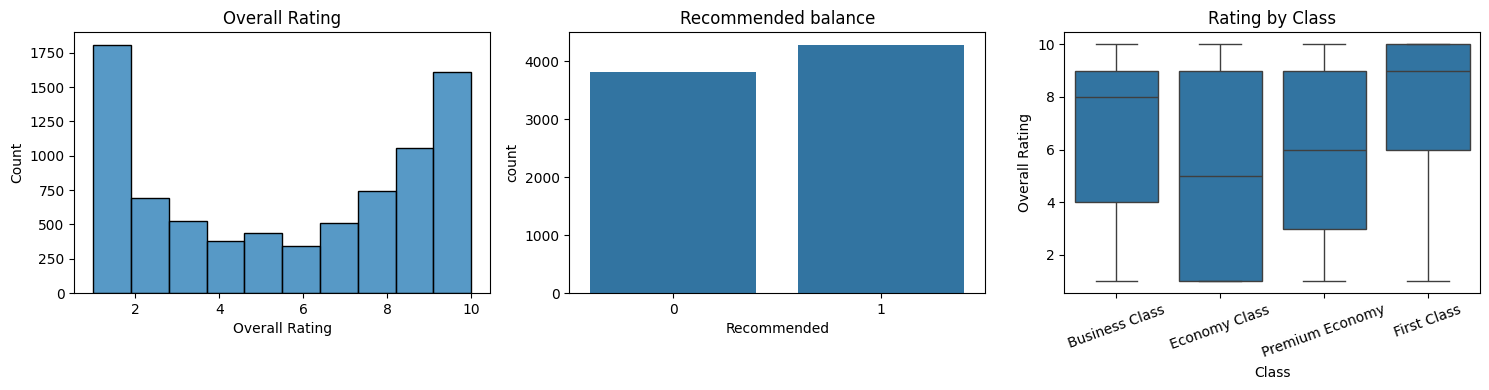

,Overall Rating
Airline,
All Nippon Airways,7.949612
EVA Air,7.419929
Qatar Airways,7.195813
Japan Airlines,7.099502
Singapore Airlines,6.542181
Korean Air,6.491979
Cathay Pacific Airways,6.169355
Emirates,4.674074
Air France,4.637845


In [13]:
# Cell 5: EDA quick checks (non-exhaustive)
fig, axes = plt.subplots(1,3, figsize=(15,4))
sns.histplot(df["Overall Rating"].dropna(), bins=10, ax=axes[0]); axes[0].set_title("Overall Rating")
sns.countplot(x="Recommended", data=df, ax=axes[1]); axes[1].set_title("Recommended balance")
sns.boxplot(x="Class", y="Overall Rating", data=df, ax=axes[2]); axes[2].set_title("Rating by Class"); plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

df.groupby("Airline")["Overall Rating"].mean().sort_values(ascending=False).head(10)


In [14]:
# Cell 6: Train/validation split with time-aware option (avoid leakage)
# If Review Date exists, sort by time and split; else random split.
df_model = df.dropna(subset=["Overall Rating","Recommended","Reviews"]).copy()

time_col = "Review Date"
if df_model[time_col].notna().mean() > 0.8:
    df_model = df_model.sort_values(time_col)
    cutoff = int(len(df_model)*0.8)
    train_df = df_model.iloc[:cutoff]
    valid_df = df_model.iloc[cutoff:]
else:
    from sklearn.model_selection import train_test_split
    train_df, valid_df = train_test_split(df_model, test_size=0.2, random_state=42, stratify=df_model["Recommended"])

train_df.shape, valid_df.shape


((6480, 19), (1620, 19))

In [15]:
# Cell 7: Classical baseline – TF-IDF + Linear/Tree
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer

text_feat = "Reviews"
cat_feats = ["Airline","Type of Traveller","Class","Route","Verified"]
num_feats = ["Seat Comfort","Staff Service","Food & Beverages","Inflight Entertainment","Value For Money","word_count"]

preproc = ColumnTransformer(transformers=[
    ("txt", TfidfVectorizer(max_features=50000, ngram_range=(1,2), min_df=2), text_feat),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
    ("num", "passthrough", num_feats)
], remainder="drop")

# Classification head for Recommended
clf = Pipeline([
    ("prep", preproc),
    ("est", LogisticRegression(max_iter=2000, n_jobs=-1))
])

# Regression head for Overall Rating
reg = Pipeline([
    ("prep", preproc),
    ("est", Ridge(alpha=1.0, random_state=42))
])

X_train = train_df[[text_feat]+cat_feats+num_feats]
X_valid = valid_df[[text_feat]+cat_feats+num_feats]

y_train_cls = train_df["Recommended"].astype(int)
y_valid_cls = valid_df["Recommended"].astype(int)

y_train_reg = train_df["Overall Rating"].astype(float)
y_valid_reg = valid_df["Overall Rating"].astype(float)

clf.fit(X_train, y_train_cls)
reg.fit(X_train, y_train_reg)

pred_cls = clf.predict(X_valid)
pred_reg = reg.predict(X_valid).clip(1,10)

acc = accuracy_score(y_valid_cls, pred_cls)
f1 = f1_score(y_valid_cls, pred_cls)
mae = mean_absolute_error(y_valid_reg, pred_reg)
r2 = r2_score(y_valid_reg, pred_reg)

print(f"Classification – Accuracy: {acc:.3f}, F1: {f1:.3f}")
print(f"Regression – MAE: {mae:.3f}, R2: {r2:.3f}")


Classification – Accuracy: 0.926, F1: 0.930
Regression – MAE: 0.991, R2: 0.847


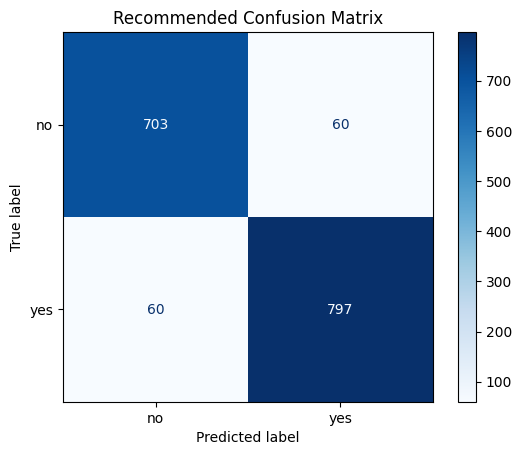

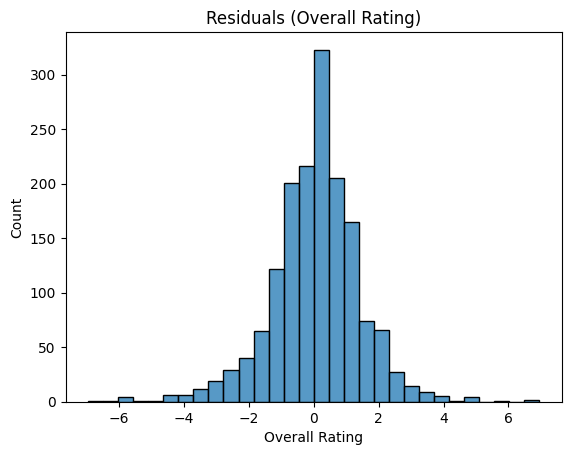

In [16]:
# Cell 8: Error analysis – calibration bins and confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

cm = confusion_matrix(y_valid_cls, pred_cls)
disp = ConfusionMatrixDisplay(cm, display_labels=["no","yes"])
disp.plot(cmap="Blues")
plt.title("Recommended Confusion Matrix")
plt.show()

# Rating residuals
resid = y_valid_reg - pred_reg
sns.histplot(resid, bins=30)
plt.title("Residuals (Overall Rating)")
plt.show()


In [17]:
# Cell 9: Simple multi-task wrapper (shared TF-IDF, two heads)
# Train two models on shared features for convenience; in production, consider multi-output estimators or joint loss training.

# Already trained: clf, reg
# Optionally stack: use reg prediction as feature for clf (and vice versa)
X_train_stack = X_train.copy()
X_valid_stack = X_valid.copy()
X_train_stack = X_train_stack.assign(pred_rating=reg.predict(X_train).clip(1,10))
X_valid_stack = X_valid_stack.assign(pred_rating=reg.predict(X_valid).clip(1,10))

clf_stack = Pipeline([
    ("prep", ColumnTransformer(transformers=[
        ("txt", TfidfVectorizer(max_features=50000, ngram_range=(1,2), min_df=2), text_feat),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
        ("num", "passthrough", num_feats+["pred_rating"])
    ], remainder="drop")),
    ("est", LogisticRegression(max_iter=2000, n_jobs=-1))
])

clf_stack.fit(train_df[[text_feat]+cat_feats+num_feats].assign(pred_rating=X_train_stack["pred_rating"]),
              y_train_cls)
pred_cls2 = clf_stack.predict(valid_df[[text_feat]+cat_feats+num_feats].assign(pred_rating=X_valid_stack["pred_rating"]))
acc2 = accuracy_score(y_valid_cls, pred_cls2)
f12 = f1_score(y_valid_cls, pred_cls2)
print(f"Stacked Classification – Accuracy: {acc2:.3f}, F1: {f12:.3f}")


Stacked Classification – Accuracy: 0.926, F1: 0.930
